# Stage 1: Missing & Invalid Data Handling
**Member:** M1 (Student ID: IT001)  
**Assigned Preprocessing Technique:** Handling Missing Values and Undocumented / Dirty Category Codes  
**Dataset:** [Default of Credit Card Clients](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients) (UCI Machine Learning Repository)  
**Pipeline Position:** Stage 1 (Sequential Initial Stage)  
**Input:** `data/raw/UCI_Credit_Card.csv`  
**Output:** `results/outputs/stage1_missing_handled.csv`

---

## 1. Explanation of the Technique

In machine learning and statistical modeling, data preparation requires verifying data integrity before running downstream transformations. While standard data cleaning checks for literal null values (`NaN`, `None`, empty strings), real-world tabular datasets frequently contain **semantic or invalid dirty codes**—values that are syntactically valid integers but violate domain codebooks.

In this stage:
1. We inspect the entire dataset for literal null values across all 24 features and 30,000 observations.
2. We examine categorical features against the official data dictionary to detect undocumented / orphan category levels.
3. We implement a systematic consolidation strategy: undocumented codes are consolidated into valid fallback categories ("Others") or imputed via the mode, preventing downstream encoding explosion and false statistical inference.

---

## 2. Justification for THIS Dataset Specifically

According to the official UCI Credit Card documentation:
- `EDUCATION`: 1 = graduate school, 2 = university, 3 = high school, 4 = others. However, values `0`, `5`, and `6` appear in the dataset without official definition.
  - Count of `0`: 14
  - Count of `5`: 280
  - Count of `6`: 51
  - Total invalid: 345 observations.
- `MARRIAGE`: 1 = married, 2 = single, 3 = others. However, value `0` appears with 54 observations.

### Why this must be Stage 1:
- If Stage 2 (Categorical Encoding) runs on raw data, one-hot encoding would create spurious dummy variables (`EDUCATION_0`, `EDUCATION_5`, `EDUCATION_6`, `MARRIAGE_0`). These columns would introduce high sparsity, multicollinearity, and fragmented degrees of freedom.
- If Stage 3 (Outlier Detection) or scaling runs first, mathematical algorithms might interpret `0`, `5`, `6` as numeric magnitudes, distorting centroid and variance calculations.
- Merging `0`, `5`, and `6` of `EDUCATION` into category `4` ("Others") and `0` of `MARRIAGE` into category `3` ("Others") preserves all 345 + 54 = 399 client records without discarding data or biasing default distributions.


In [21]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Resolve project root dynamically (searches upward for 'data' folder)
curr = os.path.abspath(os.getcwd())
while not os.path.exists(os.path.join(curr, 'data')) and os.path.dirname(curr) != curr:
    curr = os.path.dirname(curr)
project_root = curr

output_dir = os.path.join(project_root, 'results', 'outputs')
eda_dir = os.path.join(project_root, 'results', 'eda_visualizations')
os.makedirs(output_dir, exist_ok=True)
os.makedirs(eda_dir, exist_ok=True)

# 1. Load raw dataset
raw_path = os.path.join(project_root, 'data', 'raw', 'UCI_Credit_Card.csv')
df_raw = pd.read_csv(raw_path)
print(f"Loaded Raw Dataset: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
df_raw.head()


Loaded Raw Dataset: 30000 rows, 25 columns


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [22]:
# 2. Check for literal missing values (NaNs / Nulls)
null_summary = df_raw.isnull().sum()
print("Literal Missing Values Check:")
print(f"Total columns with nulls: {(null_summary > 0).sum()}")
if (null_summary > 0).sum() == 0:
    print(">> Confirmation: No literal NaNs detected across all 30,000 records.")
else:
    print(null_summary[null_summary > 0])


Literal Missing Values Check:
Total columns with nulls: 0
>> Confirmation: No literal NaNs detected across all 30,000 records.


In [23]:
# 3. Inspect semantic invalid values in EDUCATION and MARRIAGE
print("Raw EDUCATION value counts:")
print(df_raw['EDUCATION'].value_counts().sort_index())
print("\nRaw MARRIAGE value counts:")
print(df_raw['MARRIAGE'].value_counts().sort_index())


Raw EDUCATION value counts:
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

Raw MARRIAGE value counts:
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


In [24]:
# 4. Clean dirty/undocumented codes
df_cleaned = df_raw.copy()

# Consolidate EDUCATION: 0, 5, 6 -> 4 ('Others')
df_cleaned['EDUCATION'] = df_cleaned['EDUCATION'].replace({0: 4, 5: 4, 6: 4})

# Consolidate MARRIAGE: 0 -> 3 ('Others')
df_cleaned['MARRIAGE'] = df_cleaned['MARRIAGE'].replace({0: 3})

print("Post-Cleaning EDUCATION value counts (Valid: 1, 2, 3, 4):")
print(df_cleaned['EDUCATION'].value_counts().sort_index())
print("\nPost-Cleaning MARRIAGE value counts (Valid: 1, 2, 3):")
print(df_cleaned['MARRIAGE'].value_counts().sort_index())

# Save Stage 1 output CSV
curr = os.path.abspath(os.getcwd())
while not os.path.exists(os.path.join(curr, 'data')) and os.path.dirname(curr) != curr:
    curr = os.path.dirname(curr)
output_file = os.path.join(curr, 'results', 'outputs', 'stage1_missing_handled.csv')
os.makedirs(os.path.dirname(output_file), exist_ok=True)
df_cleaned.to_csv(output_file, index=False)
print(f"\nSuccessfully exported Stage 1 output to: {output_file}")


Post-Cleaning EDUCATION value counts (Valid: 1, 2, 3, 4):
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

Post-Cleaning MARRIAGE value counts (Valid: 1, 2, 3):
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64

Successfully exported Stage 1 output to: c:\Users\LENOVO\Desktop\Default-creditcard-client\results\outputs\stage1_missing_handled.csv


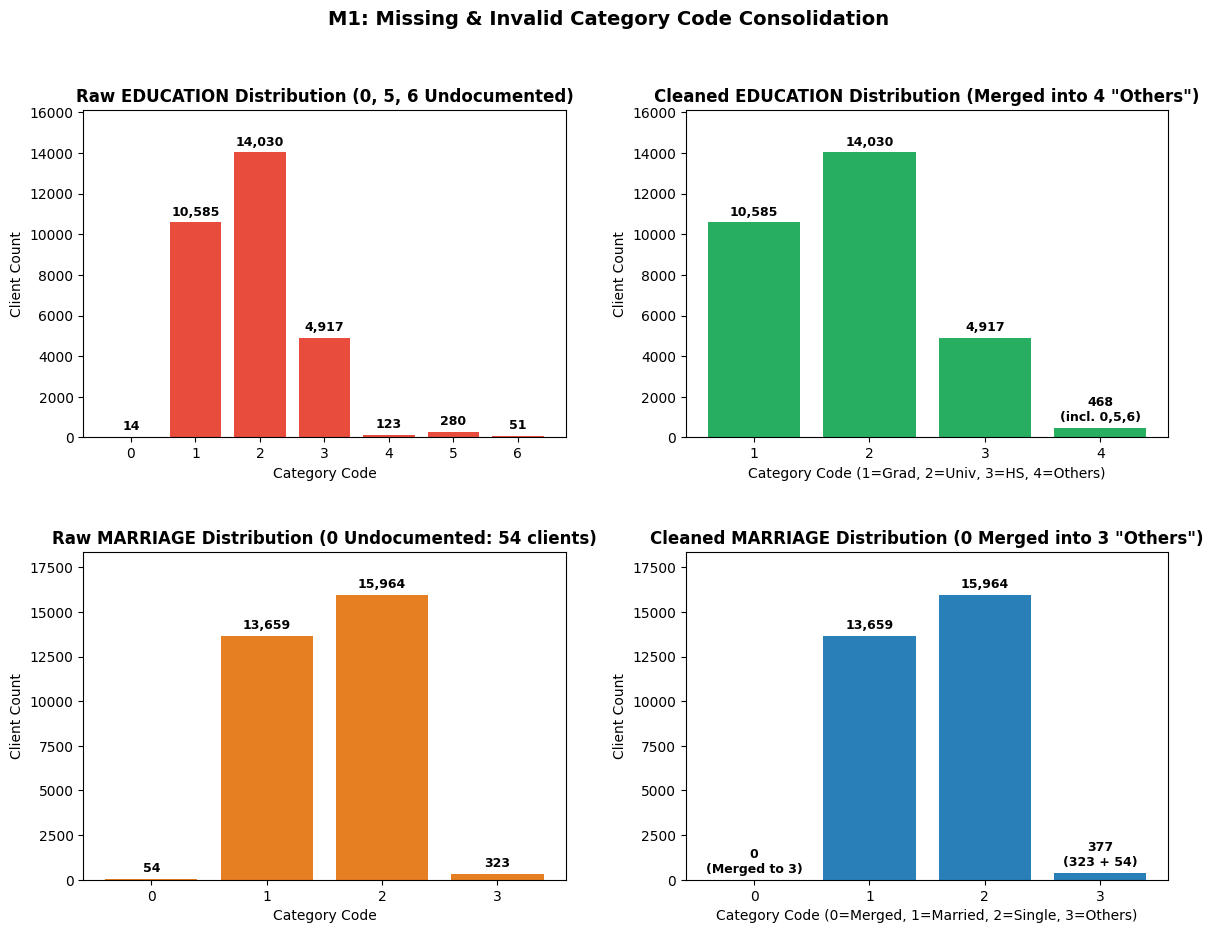

EDA plot saved to c:\Users\LENOVO\Desktop\Default-creditcard-client\results\eda_visualizations\m1_invalid_codes_distribution.png


In [25]:
# 5. EDA Visualization: Before & After Distribution of Dirty Categories
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.subplots_adjust(hspace=0.35, wspace=0.25)

# EDUCATION before
edu_raw = df_raw['EDUCATION'].value_counts().sort_index()
bars_edu_raw = axes[0, 0].bar(edu_raw.index.astype(str), edu_raw.values, color='#e74c3c')
axes[0, 0].set_title('Raw EDUCATION Distribution (0, 5, 6 Undocumented)', fontweight='bold')
axes[0, 0].set_xlabel('Category Code')
axes[0, 0].set_ylabel('Client Count')
axes[0, 0].bar_label(bars_edu_raw, padding=3, fmt='{:,.0f}', fontsize=9, fontweight='bold')
axes[0, 0].margins(y=0.15)

# EDUCATION after
edu_clean = df_cleaned['EDUCATION'].value_counts().sort_index()
bars_edu_clean = axes[0, 1].bar(edu_clean.index.astype(str), edu_clean.values, color='#27ae60')
axes[0, 1].set_title('Cleaned EDUCATION Distribution (Merged into 4 "Others")', fontweight='bold')
axes[0, 1].set_xlabel('Category Code (1=Grad, 2=Univ, 3=HS, 4=Others)')
axes[0, 1].set_ylabel('Client Count')
labels_edu_clean = [f'{v:,.0f}' if k != 4 else f'{v:,.0f}\n(incl. 0,5,6)' for k, v in edu_clean.items()]
axes[0, 1].bar_label(bars_edu_clean, labels=labels_edu_clean, padding=3, fontsize=9, fontweight='bold')
axes[0, 1].margins(y=0.15)

# MARRIAGE before
marr_raw = df_raw['MARRIAGE'].value_counts().sort_index()
bars_marr_raw = axes[1, 0].bar(marr_raw.index.astype(str), marr_raw.values, color='#e67e22')
axes[1, 0].set_title('Raw MARRIAGE Distribution (0 Undocumented: 54 clients)', fontweight='bold')
axes[1, 0].set_xlabel('Category Code')
axes[1, 0].set_ylabel('Client Count')
axes[1, 0].bar_label(bars_marr_raw, padding=3, fmt='{:,.0f}', fontsize=9, fontweight='bold')
axes[1, 0].margins(y=0.15)

# MARRIAGE after
marr_clean = df_cleaned['MARRIAGE'].value_counts().reindex([0, 1, 2, 3], fill_value=0)
bars_marr_clean = axes[1, 1].bar([str(c) for c in marr_clean.index], marr_clean.values, color='#2980b9')
axes[1, 1].set_title('Cleaned MARRIAGE Distribution (0 Merged into 3 "Others")', fontweight='bold')
axes[1, 1].set_xlabel('Category Code (0=Merged, 1=Married, 2=Single, 3=Others)')
axes[1, 1].set_ylabel('Client Count')
labels_marr_clean = ['0\n(Merged to 3)', f'{marr_clean[1]:,.0f}', f'{marr_clean[2]:,.0f}', f'{marr_clean[3]:,.0f}\n(323 + 54)']
axes[1, 1].bar_label(bars_marr_clean, labels=labels_marr_clean, padding=3, fontsize=9, fontweight='bold')
axes[1, 1].margins(y=0.15)

plt.suptitle('M1: Missing & Invalid Category Code Consolidation', fontsize=14, fontweight='bold')

# Save strictly to results/eda_visualizations in project root
curr = os.path.abspath(os.getcwd())
while not os.path.exists(os.path.join(curr, 'data')) and os.path.dirname(curr) != curr:
    curr = os.path.dirname(curr)
plot_path = os.path.join(curr, 'results', 'eda_visualizations', 'm1_invalid_codes_distribution.png')
os.makedirs(os.path.dirname(plot_path), exist_ok=True)
plt.savefig(plot_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"EDA plot saved to {plot_path}")


## 3. EDA Interpretation & Findings

1. **EDUCATION Distribution**:
   - The majority of cardholders possess a University degree (14,030, ~46.8%) followed by Graduate School (10,585, ~35.3%) and High School (4,917, ~16.4%).
   - The invalid categories `0` (14), `5` (280), and `6` (51) accounted for 345 observations (~1.15% of the data).
   - By merging them into Category `4` ("Others"), the "Others" count rose from 123 to 468 without dropping valuable records.

2. **MARRIAGE Distribution**:
   - The single population dominates (15,964, ~53.2%) followed closely by married clients (13,659, ~45.5%).
   - The invalid code `0` accounted for 54 observations (~0.18%). Merging them into `3` ("Others") brought the "Others" class to 377.

3. **Hand-off to Stage 2 (M2)**:
   - The data is now 100% clean and free of rogue category levels.
   - Stage 2 can safely perform one-hot and binary encoding on `SEX`, `EDUCATION`, and `MARRIAGE` without risk of creating extraneous sparse features.
